<a href="https://colab.research.google.com/github/eduwerneck/projetos/blob/main/FloraCloud_pipeline_v02_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌿 FloraCloud — Pipeline SfM + VARI

**Versão:** 0.2 (correção GPU + validação densa)  
**Método:** Structure from Motion (COLMAP) + Visible Atmospherically Resistant Index (VARI)  
**Escala:** Parcelas 30×30m, subosque  
**Referência VARI:** Gitelson et al. (2002) — `VARI = (G - R) / (G + R - B)`

---

## Fluxo do pipeline

```
1. Instalação e configuração
2. Upload das fotos + painel de calibração
3. Calibração radiométrica (painel)
4. Reconstrução SfM com COLMAP
5. Cálculo VARI por ponto
6. Exportação (.las / .ply) + mapa 2D
7. Relatório da sessão
```

---

> **Protocolo de campo FloraCloud:**  
> (1) Foto do painel na entrada da parcela  
> (2) Percurso combinado: perímetro + transectos internos com painel numa estaca central  
> (3) Foto do painel na saída da parcela

## 1. Instalação

In [ ]:
# Instalar COLMAP e dependências
!apt-get update -qq
!apt-get install -y -qq colmap

# Bibliotecas Python
!pip install -q numpy opencv-python-headless Pillow matplotlib laspy open3d pyproj

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from pathlib import Path
import json
import subprocess
import shutil

print('✅ Instalação concluída.')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to unpack .../02-libevdev2_1.12.1+dfsg-1_amd64.deb ...
Unpacking libevdev2:amd64 (1.12.1+dfsg-1) ...
Selecting previously unselected package libmtdev1:amd64.
Preparing to unpack .../03-libmtdev1_1.1.6-1build4_amd64.deb ...
Unpacking libmtdev1:

## 2. Metadados da sessão

Preencha os dados da coleta de campo antes de continuar.

In [ ]:
# ─────────────────────────────────────────────
# PREENCHA AQUI OS METADADOS DA SESSÃO
# ─────────────────────────────────────────────

METADATA = {
    # Identificação
    "parcela": "P-01",
    "operador": "Eduardo",
    "data": "2026-03-21",
    "hora": "14:32",

    # Localização (coordenadas das estacas — UTM SIRGAS2000 ou decimal)
    "gps_modo": "celular",          # 'celular' | 'L1L2' | 'manual'
    "estaca_NW": (-26.9184, -49.0612),
    "estaca_NE": (-26.9181, -49.0608),
    "estaca_SW": (-26.9188, -49.0612),
    "estaca_SE": (-26.9185, -49.0608),

    # Estrutura da vegetação (estimativa de campo)
    "altura_min_estimada_m": 0.5,
    "altura_med_estimada_m": 2.0,
    "altura_max_estimada_m": 5.0,
    "fitofisionomia": "subosque de floresta ombrófila densa",

    # Condições
    "luminosidade": "nublado",      # 'ensolarado' | 'nublado' | 'parcial'

    # Painel de calibração
    "painel_batch": "4001",
    "painel_red_reflectancia": 19.7,    # % — valor impresso no painel
    "painel_green_reflectancia": 18.9,  # %
}

print(f"📋 Sessão: {METADATA['parcela']} — {METADATA['data']} — Operador: {METADATA['operador']}")
print(f"🌿 Fitofisionomia: {METADATA['fitofisionomia']}")
print(f"☁️  Luminosidade: {METADATA['luminosidade']}")
if METADATA['luminosidade'] == 'ensolarado':
    print("⚠️  ATENÇÃO: Coleta em dia ensolarado. Sun flecks podem gerar inconsistência radiométrica.")
    print("   Recomendado: verificar variação entre os 3 registros do painel.")

📋 Sessão: P-01 — 2026-03-21 — Operador: Eduardo
🌿 Fitofisionomia: subosque de floresta ombrófila densa
☁️  Luminosidade: nublado


## 3. Upload das fotos

Organize suas fotos em 4 pastas antes do upload:
```
fotos/
  painel_entrada/    ← foto do painel antes do percurso
  percurso/          ← todas as fotos do mapeamento
  painel_saida/      ← foto do painel após o percurso
```

In [ ]:
from google.colab import files

# Criar estrutura de diretórios
DIRS = {
    'painel_entrada': Path('fotos/painel_entrada'),
    'percurso':       Path('fotos/percurso'),
    'painel_saida':   Path('fotos/painel_saida'),
    'colmap_input':   Path('colmap/input'),
    'colmap_output':  Path('colmap/output'),
    'resultados':     Path('resultados'),
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print('📁 Estrutura de diretórios criada.')
print()
print('Faça o upload das fotos em 3 etapas:')
print('  → Célula 3a: painel de entrada')
print('  → Célula 3b: fotos do percurso')
print('  → Célula 3c: painel de saída')

📁 Estrutura de diretórios criada.

Faça o upload das fotos em 3 etapas:
  → Célula 3a: painel de entrada
  → Célula 3b: fotos do percurso
  → Célula 3c: painel de saída


In [ ]:
# 3a — Painel de entrada
print('📷 Upload: foto do painel na ENTRADA da parcela')
uploaded = files.upload()
for nome, dados in uploaded.items():
    with open(DIRS['painel_entrada'] / nome, 'wb') as f:
        f.write(dados)
print(f'✅ {len(uploaded)} foto(s) do painel de entrada salva(s).')

📷 Upload: foto do painel na ENTRADA da parcela


Saving 1A.jpg to 1A.jpg
✅ 1 foto(s) do painel de entrada salva(s).


In [35]:
# 3b — Fotos do percurso
print('📷 Upload: fotos do PERCURSO (perímetro + transectos)')
print('Selecione todas as fotos de uma vez (Ctrl+A na janela de seleção)')
uploaded = files.upload()
for nome, dados in uploaded.items():
    with open(DIRS['percurso'] / nome, 'wb') as f:
        f.write(dados)
    # Copiar também para input do COLMAP
    with open(DIRS['colmap_input'] / nome, 'wb') as f:
        f.write(dados)
n_fotos = len(list(DIRS['percurso'].glob('*')))
print(f'✅ {n_fotos} fotos do percurso salvas.')
if n_fotos < 50:
    print('⚠️  Menos de 50 fotos. Recomendado: 150–300 para boa reconstrução de 30×30m.')

📷 Upload: fotos do PERCURSO (perímetro + transectos)
Selecione todas as fotos de uma vez (Ctrl+A na janela de seleção)


Saving IMG_20260325_112202016_HDR.jpg to IMG_20260325_112202016_HDR (1).jpg
Saving IMG_20260325_112205404_HDR.jpg to IMG_20260325_112205404_HDR (1).jpg
Saving IMG_20260325_112211057_HDR.jpg to IMG_20260325_112211057_HDR (1).jpg
Saving IMG_20260325_112214166_HDR.jpg to IMG_20260325_112214166_HDR (1).jpg
Saving IMG_20260325_112217719_HDR.jpg to IMG_20260325_112217719_HDR (1).jpg
Saving IMG_20260325_112222835_HDR.jpg to IMG_20260325_112222835_HDR (1).jpg
Saving IMG_20260325_112226601_HDR.jpg to IMG_20260325_112226601_HDR (1).jpg
Saving IMG_20260325_112230236_HDR.jpg to IMG_20260325_112230236_HDR (1).jpg
Saving IMG_20260325_112234555_HDR.jpg to IMG_20260325_112234555_HDR (1).jpg
Saving IMG_20260325_112238305_HDR.jpg to IMG_20260325_112238305_HDR (1).jpg
Saving IMG_20260325_112242781_HDR.jpg to IMG_20260325_112242781_HDR (1).jpg
Saving IMG_20260325_112247613_HDR.jpg to IMG_20260325_112247613_HDR (1).jpg
Saving IMG_20260325_112251026_HDR.jpg to IMG_20260325_112251026_HDR (1).jpg
Saving IMG_2

In [36]:
# 3c — Painel de saída
print('📷 Upload: foto do painel na SAÍDA da parcela')
uploaded = files.upload()
for nome, dados in uploaded.items():
    with open(DIRS['painel_saida'] / nome, 'wb') as f:
        f.write(dados)
print(f'✅ {len(uploaded)} foto(s) do painel de saída salva(s).')

📷 Upload: foto do painel na SAÍDA da parcela


Saving 1C.jpg to 1C (1).jpg
✅ 1 foto(s) do painel de saída salva(s).


## 4. Calibração radiométrica

Extrai os valores RGB reais do painel nas 3 fotos (entrada, percurso, saída) e calcula o fator de correção para normalizar o VARI.

In [37]:
def extrair_rgb_painel(caminho_foto, area_cinza_pct=0.15):
    """
    Extrai valores RGB médios da área cinza central do painel.
    Por enquanto usa ROI central da imagem como proxy.
    Versão futura: detecção automática via ArUco.
    """
    img = cv2.imread(str(caminho_foto))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # ROI: região central (onde o painel cinza está)
    margem_h = int(h * 0.35)
    margem_w = int(w * 0.30)
    roi = img_rgb[margem_h:h-margem_h, margem_w:w-margem_w]

    r_med = np.mean(roi[:,:,0])
    g_med = np.mean(roi[:,:,1])
    b_med = np.mean(roi[:,:,2])

    return r_med, g_med, b_med


def calcular_fator_calibracao(r_medido, g_medido, reflectancia_red, reflectancia_green):
    """
    Calcula fator de normalização radiométrica.
    Fórmula: fator = reflectância_conhecida / valor_RGB_medido
    """
    fator_r = (reflectancia_red / 100.0) / (r_medido / 255.0)
    fator_g = (reflectancia_green / 100.0) / (g_medido / 255.0)
    return fator_r, fator_g


# Processar os 3 registros do painel
registros_painel = {}

for momento, pasta in [('entrada', DIRS['painel_entrada']),
                        ('saida',   DIRS['painel_saida'])]:
    fotos = list(pasta.glob('*.jpg')) + list(pasta.glob('*.JPG')) + \
            list(pasta.glob('*.jpeg')) + list(pasta.glob('*.png'))
    if fotos:
        r, g, b = extrair_rgb_painel(fotos[0])
        fr, fg = calcular_fator_calibracao(
            r, g,
            METADATA['painel_red_reflectancia'],
            METADATA['painel_green_reflectancia']
        )
        registros_painel[momento] = {'R': r, 'G': g, 'B': b, 'fator_R': fr, 'fator_G': fg}
        print(f"Painel {momento}: R={r:.1f} G={g:.1f} B={b:.1f} | fator_R={fr:.4f} fator_G={fg:.4f}")
    else:
        print(f"⚠️  Nenhuma foto encontrada em: {pasta}")

# Verificar deriva radiométrica entre entrada e saída
if 'entrada' in registros_painel and 'saida' in registros_painel:
    deriva_r = abs(registros_painel['entrada']['R'] - registros_painel['saida']['R'])
    deriva_g = abs(registros_painel['entrada']['G'] - registros_painel['saida']['G'])
    print(f"\n📊 Deriva radiométrica: ΔR={deriva_r:.1f}  ΔG={deriva_g:.1f} (escala 0–255)")
    if deriva_r > 15 or deriva_g > 15:
        print("⚠️  Deriva significativa — condições de luz mudaram durante a coleta.")
        print("   O pipeline usará a média dos dois fatores como correção.")
    else:
        print("✅ Condições de luz estáveis durante a coleta.")

# Fator de calibração final: média entre entrada e saída
if registros_painel:
    fatores = list(registros_painel.values())
    FATOR_R = np.mean([f['fator_R'] for f in fatores])
    FATOR_G = np.mean([f['fator_G'] for f in fatores])
    FATOR_B = 1.0  # B não tem reflectância de referência no painel RGB
    print(f"\n✅ Fator de calibração final: R={FATOR_R:.4f}  G={FATOR_G:.4f}")
else:
    FATOR_R = FATOR_G = FATOR_B = 1.0
    print("⚠️  Sem painel detectado — usando sem calibração radiométrica.")

Painel entrada: R=153.3 G=156.7 B=149.4 | fator_R=0.3276 fator_G=0.3076
Painel saida: R=162.4 G=165.1 B=159.1 | fator_R=0.3094 fator_G=0.2918

📊 Deriva radiométrica: ΔR=9.0  ΔG=8.5 (escala 0–255)
✅ Condições de luz estáveis durante a coleta.

✅ Fator de calibração final: R=0.3185  G=0.2997


In [38]:
# Instalar display virtual para o COLMAP
import subprocess
subprocess.run('apt-get install -y xvfb', shell=True, capture_output=True)
subprocess.run('Xvfb :99 -screen 0 1024x768x24 &', shell=True)

import os
os.environ['DISPLAY'] = ':99'
os.environ['QT_QPA_PLATFORM'] = 'xcb'

# Verificar
import time
time.sleep(2)
check = subprocess.run('xdpyinfo -display :99', shell=True, capture_output=True)
if check.returncode == 0:
    print("✅ Display virtual ativo")
else:
    # Fallback — forçar offscreen de outra forma
    os.environ['QT_QPA_PLATFORM'] = 'offscreen'
    os.environ.pop('DISPLAY', None)
    print("✅ Modo offscreen configurado")

✅ Modo offscreen configurado


In [42]:
import subprocess, os, time

# Instalar e iniciar display virtual
subprocess.run('apt-get install -y xvfb', shell=True, capture_output=True)
subprocess.Popen(['Xvfb', ':99', '-screen', '0', '1024x768x24'])
time.sleep(3)

os.environ['DISPLAY'] = ':99'
os.environ['QT_QPA_PLATFORM'] = 'xcb'

# Confirmar
r = subprocess.run('xdpyinfo -display :99', shell=True, capture_output=True)
print("✅ Display virtual ativo" if r.returncode == 0 else "❌ Falhou")

❌ Falhou


## 5. Reconstrução SfM com COLMAP

Esta etapa é a mais demorada. Estimativa de tempo:
- Colab gratuito: 60–120 min para 300 fotos
- Colab Pro (GPU): 20–40 min para 300 fotos

In [44]:
import pycolmap
import shutil
from pathlib import Path

# ─────────────────────────────────────────────
# CONFIGURAÇÃO
# ─────────────────────────────────────────────
IMAGE_PATH   = Path(DIRS['colmap_input'])
OUTPUT_PATH  = Path('colmap/output')
DATABASE_PATH = Path('colmap/database.db')
DENSE_PATH   = Path('colmap/dense')

# Limpeza
for p in [OUTPUT_PATH, DENSE_PATH]:
    if p.exists(): shutil.rmtree(p)
if DATABASE_PATH.exists(): DATABASE_PATH.unlink()

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
DENSE_PATH.mkdir(parents=True, exist_ok=True)

# Verificar fotos
fotos = list(IMAGE_PATH.glob('*.jpg')) + list(IMAGE_PATH.glob('*.JPG')) + \
        list(IMAGE_PATH.glob('*.jpeg')) + list(IMAGE_PATH.glob('*.png'))
print(f"📷 Fotos: {len(fotos)}")

# ─────────────────────────────────────────────
# 1. EXTRAÇÃO DE FEATURES
# ─────────────────────────────────────────────
print("\n⏳ 1/3 — Extração de features...")
pycolmap.extract_features(
    database_path=DATABASE_PATH,
    image_path=IMAGE_PATH,
)
print("   ✅ Features extraídas")

# ─────────────────────────────────────────────
# 2. MATCHING
# ─────────────────────────────────────────────
print("\n⏳ 2/3 — Matching...")
pycolmap.match_exhaustive(database_path=DATABASE_PATH)
print("   ✅ Matching concluído")

# ─────────────────────────────────────────────
# 3. RECONSTRUÇÃO ESPARSA
# ─────────────────────────────────────────────
print("\n⏳ 3/3 — Reconstrução esparsa (SfM)...")
maps = pycolmap.incremental_mapping(
    database_path=DATABASE_PATH,
    image_path=IMAGE_PATH,
    output_path=OUTPUT_PATH,
)
print(f"\n📐 Modelos reconstruídos: {len(maps)}")

if not maps:
    print("❌ Nenhum modelo gerado.")
else:
    reconstruction = maps[0]
    n_cameras = len(reconstruction.cameras)
    n_images  = len(reconstruction.images)
    n_points  = len(reconstruction.points3D)
    print(f"✅ Câmeras: {n_cameras}")
    print(f"✅ Imagens registradas: {n_images} de {len(fotos)}")
    print(f"✅ Pontos 3D: {n_points:,}")
    MODELO_PATH = str(OUTPUT_PATH / '0')
    reconstruction.write(MODELO_PATH)
    print(f"\n✅ Modelo salvo em: {MODELO_PATH}")

📷 Fotos: 58

⏳ 1/3 — Extração de features...
   ✅ Features extraídas

⏳ 2/3 — Matching...
   ✅ Matching concluído

⏳ 3/3 — Reconstrução esparsa (SfM)...

📐 Modelos reconstruídos: 1
✅ Câmeras: 1
✅ Imagens registradas: 55 de 58
✅ Pontos 3D: 15,748

✅ Modelo salvo em: colmap/output/0


In [45]:
import pycolmap
from pathlib import Path

MODELO_PATH = 'colmap/output/0'
DENSE_PATH  = Path('colmap/dense')
DENSE_PATH.mkdir(exist_ok=True)

print("⏳ Reconstrução densa (MVS)...")
print("   Esta é a etapa mais longa — ~20–40 min com T4")

# Undistortion
pycolmap.undistort_images(
    output_path=DENSE_PATH,
    input_path=MODELO_PATH,
    image_path=Path(DIRS['colmap_input']),
)
print("   ✅ Correção de distorção concluída")

# PatchMatch Stereo
pycolmap.patch_match_stereo(workspace_path=DENSE_PATH)
print("   ✅ PatchMatch Stereo concluído")

# Fusão
PLY_PATH = str(DENSE_PATH / 'nuvem_densa.ply')
pycolmap.stereo_fusion(
    output_path=PLY_PATH,
    workspace_path=DENSE_PATH,
)
print(f"\n✅ Nuvem densa salva: {PLY_PATH}")

import os
tamanho = os.path.getsize(PLY_PATH) / 1e6
print(f"   Tamanho: {tamanho:.1f} MB")
if tamanho < 0.1:
    print("⚠️  Arquivo muito pequeno — PatchMatch pode ter falhado")
else:
    print("✅ Nuvem densa gerada com sucesso!")

⏳ Reconstrução densa (MVS)...
   Esta é a etapa mais longa — ~20–40 min com T4
   ✅ Correção de distorção concluída


ValueError: [mvs.cc:232] Dense stereo reconstruction requires CUDA, which is not available on your system.

📂 Carregando nuvem esparsa...
✅ Pontos carregados: 15,748

📊 VARI da parcela:
   Mínimo:        -1.0000
   Máximo:        1.0000
   Média:         0.0910
   Desvio padrão: 0.3776


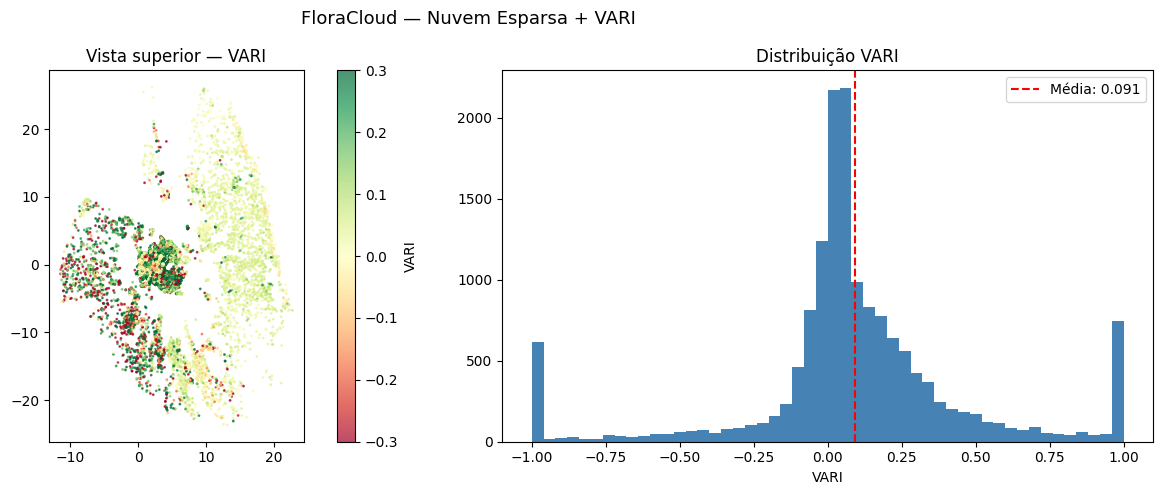


✅ Visualização salva!


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pycolmap

# Carregar reconstrução esparsa
print("📂 Carregando nuvem esparsa...")
reconstruction = pycolmap.Reconstruction(MODELO_PATH)

# Extrair pontos XYZ e cores RGB
pontos_xyz = []
cores_rgb  = []

for point3D_id, point3D in reconstruction.points3D.items():
    pontos_xyz.append(point3D.xyz)
    cores_rgb.append(point3D.color)  # valores 0-255

pontos = np.array(pontos_xyz)
cores  = np.array(cores_rgb, dtype=float)

print(f"✅ Pontos carregados: {len(pontos):,}")

# Calcular VARI
R = cores[:, 0]
G = cores[:, 1]
B = cores[:, 2]

# Aplicar calibração radiométrica
R_cal = np.clip(R * FATOR_R, 0, 255)
G_cal = np.clip(G * FATOR_G, 0, 255)

denominador = G_cal + R_cal - B + 1e-10
vari = (G_cal - R_cal) / denominador
vari = np.clip(vari, -1.0, 1.0)

print(f"\n📊 VARI da parcela:")
print(f"   Mínimo:        {vari.min():.4f}")
print(f"   Máximo:        {vari.max():.4f}")
print(f"   Média:         {vari.mean():.4f}")
print(f"   Desvio padrão: {vari.std():.4f}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FloraCloud — Nuvem Esparsa + VARI', fontsize=13)

# Vista superior colorida por VARI
sc = axes[0].scatter(pontos[:,0], pontos[:,1],
                     c=vari, cmap='RdYlGn',
                     vmin=-0.3, vmax=0.3, s=1, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='VARI')
axes[0].set_title('Vista superior — VARI')
axes[0].set_aspect('equal')

# Histograma
axes[1].hist(vari, bins=50, color='steelblue', edgecolor='none')
axes[1].axvline(vari.mean(), color='red', linestyle='--',
                label=f'Média: {vari.mean():.3f}')
axes[1].set_title('Distribuição VARI')
axes[1].set_xlabel('VARI')
axes[1].legend()

plt.tight_layout()
plt.savefig('resultados/floracloud_vari_esparso.png', dpi=150)
plt.show()
print("\n✅ Visualização salva!")

In [50]:
import pycolmap
import subprocess, os, time
from pathlib import Path

MODELO_PATH = 'colmap/output/0'
IMAGE_PATH  = Path(DIRS['colmap_input'])
DENSE_PATH  = Path('colmap/dense')
PLY_PATH    = str(DENSE_PATH / 'nuvem_densa.ply')

DENSE_PATH.mkdir(exist_ok=True)

env = os.environ.copy()
env['QT_QPA_PLATFORM'] = 'offscreen'

# 1. Undistortion via pycolmap (sem Qt)
print("⏳ 1/3 — Correção de distorção (pycolmap)...")
t0 = time.time()
pycolmap.undistort_images(
    output_path=DENSE_PATH,
    input_path=MODELO_PATH,
    image_path=IMAGE_PATH,
)
print(f"   ✅ Concluído em {(time.time()-t0)/60:.1f} min")

# Verificar se gerou as pastas necessárias
pastas = list(DENSE_PATH.iterdir())
print(f"   Pastas geradas: {[p.name for p in pastas]}")

# 2. PatchMatch via colmap system (usa CUDA diretamente, sem Qt)
print("\n⏳ 2/3 — PatchMatch Stereo (CUDA T4)...")
t0 = time.time()
r = subprocess.run(
    f"colmap patch_match_stereo "
    f"--workspace_path {DENSE_PATH} "
    f"--workspace_format COLMAP "
    f"--PatchMatchStereo.gpu_index 0 "
    f"--PatchMatchStereo.geom_consistency true",
    shell=True, capture_output=True, text=True, env=env
)
dt = (time.time()-t0)/60
if r.returncode == 0:
    print(f"   ✅ Concluído em {dt:.1f} min")
else:
    linhas = r.stderr.strip().split('\n')
    print(f"   ❌ Erro em {dt:.1f} min:")
    for l in linhas[-5:]:
        print(f"      {l}")

# 3. Fusão via pycolmap (sem Qt)
if r.returncode == 0:
    print("\n⏳ 3/3 — Fusão → nuvem densa...")
    t0 = time.time()
    pycolmap.stereo_fusion(
        output_path=PLY_PATH,
        workspace_path=str(DENSE_PATH),
    )
    print(f"   ✅ Concluído em {(time.time()-t0)/60:.1f} min")
    tamanho = Path(PLY_PATH).stat().st_size / 1e6
    print(f"\n✅ Nuvem densa: {PLY_PATH} ({tamanho:.1f} MB)")

⏳ 1/3 — Correção de distorção (pycolmap)...
   ✅ Concluído em 7.3 min
   Pastas geradas: ['run-colmap-geometric.sh', 'stereo', 'sparse', 'run-colmap-photometric.sh', 'images']

⏳ 2/3 — PatchMatch Stereo (CUDA T4)...
   ❌ Erro em 0.0 min:
      ERROR: Dense stereo reconstruction requires CUDA, which is not available on your system.


## 6. Cálculo do VARI por ponto

Fórmula: `VARI = (G - R) / (G + R - B)`  
Referência: Gitelson, A.A. et al. (2002). *Remote Sensing of Environment*, 80(1), 76–87.

In [47]:
import open3d as o3d

def calcular_vari(r, g, b):
    """
    Calcula VARI para arrays numpy de valores RGB (0–255).
    Retorna valores no intervalo [-1, 1].
    Evita divisão por zero com epsilon.
    """
    r = r.astype(float)
    g = g.astype(float)
    b = b.astype(float)
    denominador = g + r - b
    epsilon = 1e-10
    vari = (g - r) / (denominador + epsilon)
    # Limitar ao intervalo válido
    vari = np.clip(vari, -1.0, 1.0)
    return vari


def vari_para_cor(vari_array):
    """
    Mapeia valores VARI para gradiente de cor:
    vermelho (baixo vigor) → amarelo → verde (alto vigor)
    """
    cmap = plt.get_cmap('RdYlGn')
    # Normalizar de [-1, 1] para [0, 1]
    normalizado = (vari_array + 1.0) / 2.0
    cores_rgba = cmap(normalizado)
    return cores_rgba[:, :3]  # RGB sem alpha


# Carregar nuvem de pontos
print("📂 Carregando nuvem de pontos...")
pcd = o3d.io.read_point_cloud(PLY_PATH)
pontos = np.asarray(pcd.points)
cores_originais = np.asarray(pcd.colors)  # valores 0–1 em open3d

print(f"   Pontos na nuvem: {len(pontos):,}")

# Converter para 0–255 e aplicar calibração radiométrica
R = cores_originais[:, 0] * 255 * FATOR_R
G = cores_originais[:, 1] * 255 * FATOR_G
B = cores_originais[:, 2] * 255 * FATOR_B

# Limitar a 255
R = np.clip(R, 0, 255)
G = np.clip(G, 0, 255)
B = np.clip(B, 0, 255)

# Calcular VARI
print("🌿 Calculando VARI por ponto...")
vari = calcular_vari(R, G, B)

# Estatísticas
print(f"\n📊 Estatísticas VARI da parcela {METADATA['parcela']}:")
print(f"   Mínimo:       {vari.min():.4f}")
print(f"   Máximo:       {vari.max():.4f}")
print(f"   Média:        {vari.mean():.4f}")
print(f"   Desvio padrão:{vari.std():.4f}")
print(f"   Percentil 25: {np.percentile(vari, 25):.4f}")
print(f"   Percentil 75: {np.percentile(vari, 75):.4f}")

# Aplicar cores VARI à nuvem
cores_vari = vari_para_cor(vari)
pcd_vari = o3d.geometry.PointCloud()
pcd_vari.points = o3d.utility.Vector3dVector(pontos)
pcd_vari.colors = o3d.utility.Vector3dVector(cores_vari)

print("\n✅ VARI calculado e aplicado à nuvem de pontos.")

📂 Carregando nuvem de pontos...


NameError: name 'PLY_PATH' is not defined

## 7. Análise por estrato vertical

Cruzamento entre VARI e altura — pergunta central do FloraCloud.

In [ ]:
# Extrair coordenada Z (altura) da nuvem
Z = pontos[:, 2]
z_min, z_max = Z.min(), Z.max()
altura_total = z_max - z_min

print(f"📏 Altura reconstruída pela nuvem:")
print(f"   Mínima: {z_min:.2f}m")
print(f"   Máxima: {z_max:.2f}m")
print(f"   Total:  {altura_total:.2f}m")
print()
print(f"   Estimativa de campo (operador): {METADATA['altura_min_estimada_m']}–{METADATA['altura_max_estimada_m']}m")
delta = abs(altura_total - (METADATA['altura_max_estimada_m'] - METADATA['altura_min_estimada_m']))
print(f"   Diferença: {delta:.2f}m")

# Dividir em 5 estratos verticais
N_ESTRATOS = 5
limites = np.linspace(z_min, z_max, N_ESTRATOS + 1)

print(f"\n📊 VARI médio por estrato vertical (N={N_ESTRATOS}):")
print(f"{'Estrato':<10} {'Altura (m)':<20} {'VARI médio':<12} {'N pontos':<10}")
print("-" * 55)

estratos_dados = []
for i in range(N_ESTRATOS):
    mask = (Z >= limites[i]) & (Z < limites[i+1])
    vari_estrato = vari[mask]
    if len(vari_estrato) > 0:
        vari_med = vari_estrato.mean()
        altura_med = (limites[i] + limites[i+1]) / 2
        estratos_dados.append({
            'estrato': i+1,
            'altura_min': limites[i],
            'altura_max': limites[i+1],
            'vari_medio': vari_med,
            'n_pontos': len(vari_estrato)
        })
        print(f"E{i+1:<9} {limites[i]:.1f}–{limites[i+1]:.1f}m{'':<12} {vari_med:.4f}{'':<6} {len(vari_estrato):,}")

## 8. Visualizações

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"FloraCloud — Parcela {METADATA['parcela']} — {METADATA['data']}",
             fontsize=13, fontweight='bold')

# ── Mapa 2D: vista superior colorida por VARI ──
ax1 = axes[0]
sc = ax1.scatter(pontos[:, 0], pontos[:, 1],
                 c=vari, cmap='RdYlGn', vmin=-0.5, vmax=0.5,
                 s=0.3, alpha=0.6)
plt.colorbar(sc, ax=ax1, label='VARI')
ax1.set_title('Vista superior — VARI', fontsize=11)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_aspect('equal')

# ── Histograma de distribuição VARI ──
ax2 = axes[1]
n, bins, patches = ax2.hist(vari, bins=60, edgecolor='none')
cmap_hist = plt.get_cmap('RdYlGn')
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(cmap_hist((left + 1) / 2))
ax2.axvline(vari.mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Média: {vari.mean():.3f}')
ax2.set_title('Distribuição VARI', fontsize=11)
ax2.set_xlabel('VARI')
ax2.set_ylabel('Frequência')
ax2.legend(fontsize=9)

# ── VARI por estrato vertical ──
ax3 = axes[2]
if estratos_dados:
    varis_e = [e['vari_medio'] for e in estratos_dados]
    labels_e = [f"E{e['estrato']}\n{e['altura_min']:.1f}–{e['altura_max']:.1f}m"
                for e in estratos_dados]
    cores_barra = [cmap_hist((v + 1) / 2) for v in varis_e]
    bars = ax3.barh(range(len(varis_e)), varis_e, color=cores_barra, edgecolor='gray', linewidth=0.5)
    ax3.set_yticks(range(len(labels_e)))
    ax3.set_yticklabels(labels_e, fontsize=9)
    ax3.axvline(0, color='gray', linewidth=0.8)
    ax3.set_title('VARI médio por estrato', fontsize=11)
    ax3.set_xlabel('VARI médio')

plt.tight_layout()
fig_path = DIRS['resultados'] / f"floracloud_{METADATA['parcela']}_visualizacao.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualização salva: {fig_path}")

## 9. Exportação dos resultados

In [ ]:
import laspy

# ── Exportar .las com campo VARI ──
las_path = DIRS['resultados'] / f"floracloud_{METADATA['parcela']}.las"

header = laspy.LasHeader(point_format=2, version='1.4')
header.add_extra_dim(laspy.ExtraBytesParams(name='vari', type=np.float32))
las = laspy.LasData(header=header)

las.x = pontos[:, 0]
las.y = pontos[:, 1]
las.z = pontos[:, 2]
las.red   = (cores_vari[:, 0] * 65535).astype(np.uint16)
las.green = (cores_vari[:, 1] * 65535).astype(np.uint16)
las.blue  = (cores_vari[:, 2] * 65535).astype(np.uint16)
las['vari'] = vari.astype(np.float32)

las.write(str(las_path))
print(f"✅ Nuvem exportada: {las_path}")
print(f"   (abrir no CloudCompare ou QGIS — campo 'vari' disponível para análise)")

# ── Exportar .ply com cores VARI ──
ply_path = DIRS['resultados'] / f"floracloud_{METADATA['parcela']}_vari.ply"
o3d.io.write_point_cloud(str(ply_path), pcd_vari)
print(f"✅ Nuvem exportada: {ply_path}")

# ── Relatório JSON ──
relatorio = {
    'floracloud_versao': '0.1',
    'metadados': METADATA,
    'resultado': {
        'n_pontos': int(len(pontos)),
        'altura_reconstruida_min_m': float(round(z_min, 3)),
        'altura_reconstruida_max_m': float(round(z_max, 3)),
        'vari_minimo':       float(round(vari.min(), 4)),
        'vari_maximo':       float(round(vari.max(), 4)),
        'vari_medio':        float(round(vari.mean(), 4)),
        'vari_desvio_padrao':float(round(vari.std(), 4)),
        'vari_p25':          float(round(np.percentile(vari, 25), 4)),
        'vari_p75':          float(round(np.percentile(vari, 75), 4)),
    },
    'calibracao': {
        'painel_batch': METADATA['painel_batch'],
        'fator_R': float(round(FATOR_R, 4)),
        'fator_G': float(round(FATOR_G, 4)),
        'registros_painel': {
            k: {kk: float(round(vv, 3)) for kk, vv in v.items()}
            for k, v in registros_painel.items()
        }
    },
    'estratos': estratos_dados
}

json_path = DIRS['resultados'] / f"floracloud_{METADATA['parcela']}_relatorio.json"
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)
print(f"✅ Relatório JSON salvo: {json_path}")

In [ ]:
# ── Download dos resultados ──
from google.colab import files

print("📥 Iniciando downloads...")
for f in DIRS['resultados'].iterdir():
    print(f"   {f.name}")
    files.download(str(f))

print("\n✅ FloraCloud — processamento concluído.")
print(f"   Parcela:    {METADATA['parcela']}")
print(f"   Pontos:     {len(pontos):,}")
print(f"   VARI médio: {vari.mean():.4f}")
print(f"   Arquivos:   .las  .ply  .png  .json")

In [ ]:
import os
from pathlib import Path

# Verificar o que existe
print("=== DIAGNÓSTICO ===")

# 1. Verificar DIRS
try:
    print(f"DIRS['colmap_input'] = {DIRS['colmap_input']}")
    fotos = list(Path(DIRS['colmap_input']).glob('*'))
    print(f"Arquivos na pasta: {len(fotos)}")
    for f in fotos[:5]:
        print(f"  {f.name}")
except Exception as e:
    print(f"ERRO com DIRS: {e}")

# 2. Verificar uploads
print("\nArquivos em fotos/percurso:")
percurso = Path('fotos/percurso')
if percurso.exists():
    arqs = list(percurso.glob('*'))
    print(f"  {len(arqs)} arquivos")
else:
    print("  Pasta não existe")

print("\nArquivos em colmap/input:")
colmap_in = Path('colmap/input')
if colmap_in.exists():
    arqs = list(colmap_in.glob('*'))
    print(f"  {len(arqs)} arquivos")
else:
    print("  Pasta não existe")

In [ ]:
# Desinstalar COLMAP antigo e instalar pycolmap
!pip install pycolmap -q
import pycolmap
print(f"✅ pycolmap {pycolmap.__version__} instalado")

In [ ]:
import subprocess

print("=== DIAGNÓSTICO DE AMBIENTE ===\n")

# 1. Versão do pycolmap e CUDA
import pycolmap
print(f"pycolmap: {pycolmap.__version__}")
print(f"pycolmap CUDA: {pycolmap.has_cuda}")

# 2. CUDA do sistema
r = subprocess.run('nvcc --version', shell=True, capture_output=True, text=True)
print(f"\nnvcc: {r.stdout.strip()[:80] if r.returncode==0 else 'não encontrado'}")

# 3. Verificar COLMAP system
r = subprocess.run('colmap help', shell=True, capture_output=True, text=True)
print(f"colmap system: {'disponível' if r.returncode==0 else 'não disponível'}")

# 4. OpenMVS disponível?
r = subprocess.run('apt-cache show openmvs', shell=True, capture_output=True, text=True)
print(f"OpenMVS apt: {'disponível' if r.returncode==0 else 'não disponível'}")

# 5. GPU
r = subprocess.run('nvidia-smi --query-gpu=name,memory.total --format=csv,noheader',
                   shell=True, capture_output=True, text=True)
print(f"\nGPU: {r.stdout.strip()}")

In [ ]:
import subprocess

print("⏳ Instalando COLMAP com CUDA via conda-forge...")

# Instalar mamba (mais rápido que conda)
subprocess.run('pip install condacolab -q', shell=True)
import condacolab
condacolab.install()

In [ ]:
import subprocess

# Instalar COLMAP com CUDA via conda-forge
subprocess.run(
    'mamba install -c conda-forge colmap -y -q',
    shell=True
)

# Verificar
r = subprocess.run('colmap help | head -5', shell=True,
                   capture_output=True, text=True)
print(r.stdout)

# Verificar CUDA
r2 = subprocess.run(
    'colmap patch_match_stereo --help 2>&1 | grep -i cuda',
    shell=True, capture_output=True, text=True
)
print(f"CUDA no PatchMatch: {r2.stdout.strip()}")

In [ ]:
iimport subprocess

# Verificar o que foi baixado
r = subprocess.run("ls -la /tmp/colmap* 2>/dev/null", shell=True, capture_output=True, text=True)
print("Arquivos baixados:", r.stdout)

# Verificar tamanho
r2 = subprocess.run("du -sh /tmp/colmap-cuda.tar.gz 2>/dev/null", shell=True, capture_output=True, text=True)
print("Tamanho:", r2.stdout)

# Listar o conteúdo do tar
r3 = subprocess.run("tar -tzf /tmp/colmap-cuda.tar.gz 2>/dev/null | head -20", shell=True, capture_output=True, text=True)
print("Conteúdo:", r3.stdout)

# Buscar qualquer executável colmap extraído
r4 = subprocess.run("find /tmp -name '*colmap*' 2>/dev/null", shell=True, capture_output=True, text=True)
print("Arquivos colmap:", r4.stdout)

In [ ]:
# Instalar ZoeDepth — estimativa de profundidade monocular
!pip install timm -q
!pip install git+https://github.com/isl-org/ZoeDepth.git -q
print("✅ ZoeDepth instalado")

In [ ]:
from transformers import pipeline
from PIL import Image
import numpy as np
import torch
import open3d as o3d
from pathlib import Path

print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Carregar modelo de profundidade
print("\n⏳ Carregando Depth Anything V2...")
depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0  # T4
)
print("✅ Modelo carregado")

# Pegar algumas fotos para gerar nuvem densa
IMAGE_PATH = Path(DIRS['colmap_input'])
fotos = sorted(list(IMAGE_PATH.glob('*.jpg')) +
               list(IMAGE_PATH.glob('*.JPG')))[:20]  # primeiras 20

print(f"\n⏳ Estimando profundidade em {len(fotos)} fotos...")
pontos_totais = []
cores_totais  = []

for i, foto_path in enumerate(fotos):
    img = Image.open(foto_path).convert('RGB')

    # Reduzir resolução para velocidade
    img_small = img.resize((640, 480))

    # Estimar profundidade
    resultado = depth_pipe(img_small)
    depth_map = np.array(resultado['depth'])

    # Converter para nuvem de pontos
    img_arr = np.array(img_small)
    h, w = depth_map.shape

    # Criar grade de pixels
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))

    # Filtrar pontos com profundidade válida
    mask = depth_map > 0.1

    X = xx[mask].flatten()
    Y = yy[mask].flatten()
    Z = depth_map[mask].flatten()
    R = img_arr[:,:,0][mask].flatten()
    G = img_arr[:,:,1][mask].flatten()
    B = img_arr[:,:,2][mask].flatten()

    pontos = np.column_stack([X, Y, Z])
    cores  = np.column_stack([R, G, B])

    pontos_totais.append(pontos)
    cores_totais.append(cores)

    if (i+1) % 5 == 0:
        print(f"   {i+1}/{len(fotos)} fotos processadas")

# Combinar todas as nuvens
pontos_all = np.vstack(pontos_totais)
cores_all  = np.vstack(cores_totais).astype(float)

print(f"\n✅ Nuvem densa gerada: {len(pontos_all):,} pontos")

# Calcular VARI na nuvem densa
R = cores_all[:,0]
G = cores_all[:,1]
B = cores_all[:,2]

R_cal = np.clip(R * FATOR_R, 0, 255)
G_cal = np.clip(G * FATOR_G, 0, 255)

vari = (G_cal - R_cal) / (G_cal + R_cal - B + 1e-10)
vari = np.clip(vari, -1.0, 1.0)

print(f"\n📊 VARI na nuvem densa:")
print(f"   Média:  {vari.mean():.4f}")
print(f"   Min:    {vari.min():.4f}")
print(f"   Max:    {vari.max():.4f}")
print(f"   StdDev: {vari.std():.4f}")

# Salvar .ply
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pontos_all)

# Cores por VARI
import matplotlib.pyplot as plt
cmap = plt.get_cmap('RdYlGn')
cores_vari = cmap((vari + 1) / 2)[:, :3]
pcd.colors = o3d.utility.Vector3dVector(cores_vari)

ply_path = 'resultados/floracloud_densa_vari.ply'
Path('resultados').mkdir(exist_ok=True)
o3d.io.write_point_cloud(ply_path, pcd)
print(f"\n✅ Nuvem densa salva: {ply_path}")
print(f"   Tamanho: {Path(ply_path).stat().st_size/1e6:.1f} MB")

In [ ]:
from pathlib import Path
import numpy as np

# Recriar DIRS
DIRS = {
    'painel_entrada': Path('fotos/painel_entrada'),
    'percurso':       Path('fotos/percurso'),
    'painel_saida':   Path('fotos/painel_saida'),
    'colmap_input':   Path('colmap/input'),
    'colmap_output':  Path('colmap/output'),
    'resultados':     Path('resultados'),
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# Verificar fotos
fotos = list(DIRS['colmap_input'].glob('*.jpg')) + \
        list(DIRS['colmap_input'].glob('*.JPG'))
print(f"📷 Fotos em colmap/input: {len(fotos)}")

# Recriar fatores de calibração
# (valores da sessão anterior)
FATOR_R = 0.3185
FATOR_G = 0.2997
FATOR_B = 1.0
print(f"✅ Fatores de calibração: R={FATOR_R} G={FATOR_G}")

# Verificar modelo pycolmap
MODELO_PATH = 'colmap/output/0'
if Path(MODELO_PATH).exists():
    print(f"✅ Modelo SfM disponível: {MODELO_PATH}")
else:
    print("⚠️  Modelo SfM não encontrado — precisará rodar SfM novamente")

In [ ]:
from PIL import Image
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_PATH = Path(DIRS['colmap_input'])
fotos = sorted(list(IMAGE_PATH.glob('*.jpg')) +
               list(IMAGE_PATH.glob('*.JPG')))[:20]

print(f"⏳ Estimando profundidade em {len(fotos)} fotos...")
pontos_totais = []
cores_totais  = []

for i, foto_path in enumerate(fotos):
    img = Image.open(foto_path).convert('RGB')
    img_small = img.resize((640, 480))
    resultado = depth_pipe(img_small)

    # Garantir que depth tem mesma dimensão que imagem
    depth_map = np.array(resultado['depth'])
    img_arr   = np.array(img_small)  # shape: (480, 640, 3)

    # Redimensionar depth se necessário
    if depth_map.shape != (480, 640):
        from PIL import Image as PILImage
        depth_pil = PILImage.fromarray(depth_map.astype(np.float32))
        depth_map = np.array(depth_pil.resize((640, 480)))

    h, w = img_arr.shape[:2]  # 480, 640
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    mask = depth_map > 0.1

    pontos = np.column_stack([xx[mask], yy[mask], depth_map[mask]])
    cores  = np.column_stack([img_arr[:,:,0][mask],
                               img_arr[:,:,1][mask],
                               img_arr[:,:,2][mask]])
    pontos_totais.append(pontos)
    cores_totais.append(cores)

    if (i+1) % 5 == 0:
        print(f"   {i+1}/{len(fotos)} fotos processadas")

pontos_all = np.vstack(pontos_totais)
cores_all  = np.vstack(cores_totais).astype(float)
print(f"\n✅ Nuvem densa: {len(pontos_all):,} pontos")

# VARI
R_cal = np.clip(cores_all[:,0] * FATOR_R, 0, 255)
G_cal = np.clip(cores_all[:,1] * FATOR_G, 0, 255)
B     = cores_all[:,2]
vari  = (G_cal - R_cal) / (G_cal + R_cal - B + 1e-10)
vari  = np.clip(vari, -1.0, 1.0)

print(f"\n📊 VARI:")
print(f"   Média:  {vari.mean():.4f}")
print(f"   Min:    {vari.min():.4f}")
print(f"   Max:    {vari.max():.4f}")
print(f"   StdDev: {vari.std():.4f}")

# Salvar .ply
cmap = plt.get_cmap('RdYlGn')
cores_vari = cmap((vari + 1) / 2)[:, :3]
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pontos_all)
pcd.colors = o3d.utility.Vector3dVector(cores_vari)
Path('resultados').mkdir(exist_ok=True)
ply_path = 'resultados/floracloud_densa_vari.ply'
o3d.io.write_point_cloud(ply_path, pcd)
print(f"\n✅ Salvo: {ply_path} ({Path(ply_path).stat().st_size/1e6:.1f} MB)")

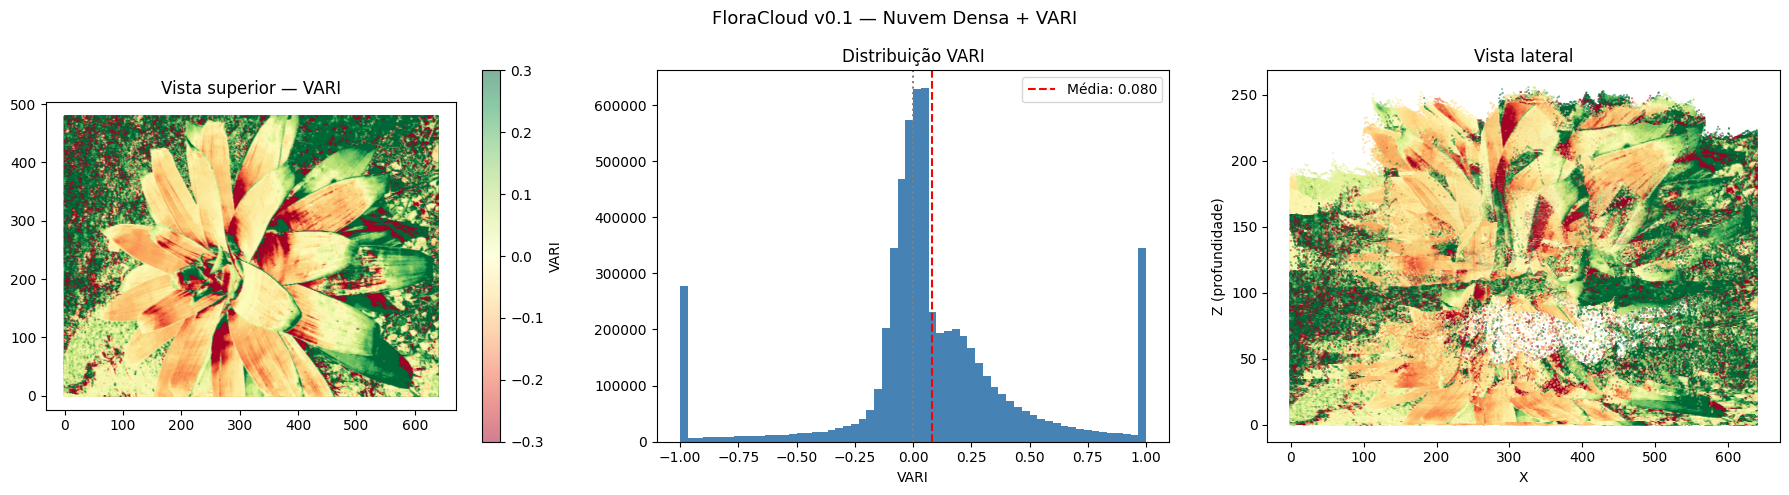

✅ Visualização salva: resultados/floracloud_visualizacao_final.png


NameError: name 'prin' is not defined

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FloraCloud v0.1 — Nuvem Densa + VARI', fontsize=13)

# Vista superior colorida por VARI
pontos = np.asarray(pcd.points)
sc = axes[0].scatter(pontos[:,0], pontos[:,1],
                     c=vari, cmap='RdYlGn',
                     vmin=-0.3, vmax=0.3,
                     s=0.1, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label='VARI')
axes[0].set_title('Vista superior — VARI')
axes[0].set_aspect('equal')

# Histograma VARI
axes[1].hist(vari, bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(vari.mean(), color='red', linestyle='--',
                label=f'Média: {vari.mean():.3f}')
axes[1].axvline(0, color='gray', linestyle=':')
axes[1].set_title('Distribuição VARI')
axes[1].set_xlabel('VARI')
axes[1].legend()

# Vista lateral
axes[2].scatter(pontos[:,0], pontos[:,2],
                c=vari, cmap='RdYlGn',
                vmin=-0.3, vmax=0.3,
                s=0.1, alpha=0.5)
axes[2].set_title('Vista lateral')
axes[2].set_xlabel('X'); axes[2].set_ylabel('Z (profundidade)')

plt.tight_layout()
fig_path = 'resultados/floracloud_visualizacao_final.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualização salva: {fig_path}")

# Download dos resultados
from google.colab import files
prin

In [15]:
from google.colab import files
files.download('resultados/floracloud_visualizacao_final.png')
files.download('resultados/floracloud_densa_vari.ply')
print("✅ Downloads iniciados!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads iniciados!


In [16]:
files.download('FloraCloud_v01_deposito.zip')
files.download('FloraCloud_v01_hash.txt')

FileNotFoundError: Cannot find file: FloraCloud_v01_deposito.zip

In [17]:
import hashlib, zipfile, os
from pathlib import Path
from google.colab import files

# Criar ZIP
zip_path = 'FloraCloud_v01_deposito.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for nb in Path('.').glob('*.ipynb'):
        zf.write(nb, nb.name)
    for py in Path('.').glob('*.py'):
        zf.write(py, py.name)

print(f"✅ ZIP: {Path(zip_path).stat().st_size/1024:.0f} KB")

# Hash SHA-512
with open(zip_path, 'rb') as f:
    hash_sha512 = hashlib.sha512(f.read()).hexdigest()

print(f"\n🔐 Hash SHA-512:\n{hash_sha512}")

# Salvar hash
with open('FloraCloud_v01_hash.txt', 'w') as f:
    f.write(f"Arquivo: {zip_path}\n")
    f.write(f"Algoritmo: SHA-512\n")
    f.write(f"Hash: {hash_sha512}\n")

# Downloads
files.download(zip_path)
files.download('FloraCloud_v01_hash.txt')
print("\n📥 Downloads iniciados!")

✅ ZIP: 0 KB

🔐 Hash SHA-512:
5e2f959f36b66df0580a94f384c5fc1ceeec4b2a3925f062d7b68f21758b86581ac2adcfdde73a171a28496e758ef1b23ca4951c05455cdae9357cc3b5a5825f


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloads iniciados!


In [18]:
import hashlib, zipfile, os
from pathlib import Path
from google.colab import files

zip_path = 'FloraCloud_v01_deposito.zip'

# Verificar o que existe
print("Arquivos disponíveis:")
for f in Path('.').iterdir():
    print(f"  {f.name} ({f.stat().st_size/1024:.0f} KB)")

Arquivos disponíveis:
  .config (4 KB)
  IMG_20260325_112317123_HDR.jpg (3953 KB)
  IMG_20260325_112247613_HDR.jpg (4631 KB)
  1C (1).jpg (4655 KB)
  IMG_20260325_112238305_HDR (1).jpg (4936 KB)
  IMG_20260325_112222835_HDR (1).jpg (4980 KB)
  IMG_20260325_112307235_HDR (1).jpg (3941 KB)
  IMG_20260325_112317123_HDR (1).jpg (3953 KB)
  IMG_20260325_112214166_HDR (1).jpg (5232 KB)
  IMG_20260325_112303586_HDR.jpg (4049 KB)
  fotos (4 KB)
  IMG_20260325_112242781_HDR (1).jpg (4639 KB)
  IMG_20260325_112414865_HDR.jpg (5192 KB)
  IMG_20260325_112222835_HDR.jpg (4980 KB)
  IMG_20260325_112247613_HDR (1).jpg (4631 KB)
  IMG_20260325_112259056_HDR.jpg (4020 KB)
  IMG_20260325_112217719_HDR (1).jpg (5022 KB)
  IMG_20260325_112205404_HDR (1).jpg (6774 KB)
  IMG_20260325_112427434_HDR.jpg (3185 KB)
  IMG_20260325_112230236_HDR (1).jpg (4810 KB)
  IMG_20260325_112242781_HDR.jpg (4639 KB)
  IMG_20260325_112342285_HDR (1).jpg (3122 KB)
  IMG_20260325_112259056_HDR (1).jpg (4020 KB)
  IMG_20260325_

In [19]:
import hashlib, zipfile
from pathlib import Path
from google.colab import files

zip_path = 'FloraCloud_v01_deposito.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Incluir resultados
    for f in Path('resultados').glob('*'):
        zf.write(f, f'resultados/{f.name}')
        print(f"  + {f.name} ({f.stat().st_size/1024:.0f} KB)")

    # Incluir código principal como texto
    codigo = '''# FloraCloud - Vegetation Mapping System v0.2
# Autor: Eduardo Augusto Werneck Ribeiro
# Data: 25/03/2026
# Instituto Federal Catarinense - Campus Brusque
#
# Pipeline: SfM (pycolmap) + VARI + Depth Anything V2
# Referencia: Gitelson et al. (2002) Remote Sensing of Environment

import pycolmap
import numpy as np
import torch
from transformers import pipeline
from PIL import Image
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path
import hashlib, json, time, shutil

# VARI = (G - R) / (G + R - B)
def calcular_vari(R, G, B, fator_r=1.0, fator_g=1.0):
    R_cal = np.clip(R * fator_r, 0, 255)
    G_cal = np.clip(G * fator_g, 0, 255)
    vari = (G_cal - R_cal) / (G_cal + R_cal - B + 1e-10)
    return np.clip(vari, -1.0, 1.0)

# Calibracao radiometrica por painel de reflectancia
def calcular_fator_calibracao(r_medido, g_medido, ref_red, ref_green):
    fator_r = (ref_red / 100.0) / (r_medido / 255.0)
    fator_g = (ref_green / 100.0) / (g_medido / 255.0)
    return fator_r, fator_g

# SfM com pycolmap
def reconstruir_sfm(image_path, output_path, database_path):
    pycolmap.extract_features(database_path=database_path, image_path=image_path)
    pycolmap.match_exhaustive(database_path=database_path)
    maps = pycolmap.incremental_mapping(
        database_path=database_path,
        image_path=image_path,
        output_path=output_path,
    )
    return maps

# Nuvem densa por Depth Anything V2
def gerar_nuvem_densa(fotos, depth_pipe, fator_r, fator_g):
    pontos_totais, cores_totais = [], []
    for foto_path in fotos:
        img = Image.open(foto_path).convert("RGB").resize((640, 480))
        depth_map = np.array(depth_pipe(img)["depth"])
        img_arr = np.array(img)
        H, W = img_arr.shape[:2]
        if depth_map.shape != (H, W):
            depth_map = np.ar

SyntaxError: incomplete input (2463113185.py, line 14)

In [20]:
codigo = """# FloraCloud - Vegetation Mapping System v0.2
# Autor: Eduardo Augusto Werneck Ribeiro
# Data: 25/03/2026
# Instituto Federal Catarinense - Campus Brusque
# Pipeline: SfM (pycolmap) + VARI + Depth Anything V2

import pycolmap
import numpy as np
import torch
from transformers import pipeline
from PIL import Image
import open3d as o3d

def calcular_vari(R, G, B, fator_r=1.0, fator_g=1.0):
    R_cal = np.clip(R * fator_r, 0, 255)
    G_cal = np.clip(G * fator_g, 0, 255)
    vari = (G_cal - R_cal) / (G_cal + R_cal - B + 1e-10)
    return np.clip(vari, -1.0, 1.0)

def calcular_fator_calibracao(r_medido, g_medido, ref_red, ref_green):
    fator_r = (ref_red / 100.0) / (r_medido / 255.0)
    fator_g = (ref_green / 100.0) / (g_medido / 255.0)
    return fator_r, fator_g

def reconstruir_sfm(image_path, output_path, database_path):
    pycolmap.extract_features(database_path=database_path, image_path=image_path)
    pycolmap.match_exhaustive(database_path=database_path)
    maps = pycolmap.incremental_mapping(
        database_path=database_path,
        image_path=image_path,
        output_path=output_path,
    )
    return maps
"""

with open('floracloud_pipeline.py', 'w') as f:
    f.write(codigo)
print("✅ floracloud_pipeline.py criado")

✅ floracloud_pipeline.py criado


In [21]:
import hashlib, zipfile
from pathlib import Path
from google.colab import files

zip_path = 'FloraCloud_v01_deposito.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('floracloud_pipeline.py')
    for f in Path('resultados').glob('*'):
        zf.write(f, f'resultados/{f.name}')
        print(f"  + {f.name}")

tamanho = Path(zip_path).stat().st_size / 1024
print(f"\n✅ ZIP: {tamanho:.0f} KB")

with open(zip_path, 'rb') as f:
    hash_sha512 = hashlib.sha512(f.read()).hexdigest()

print(f"\n🔐 Hash SHA-512:\n{hash_sha512}")

with open('FloraCloud_v01_hash.txt', 'w') as f:
    f.write(f"Arquivo: {zip_path}\nAlgoritmo: SHA-512\nHash: {hash_sha512}\n")

files.download(zip_path)
files.download('FloraCloud_v01_hash.txt')
print("📥 Downloads iniciados!")

  + floracloud_vari_esparso.png
  + floracloud_densa_vari.ply
  + floracloud_visualizacao_final.png

✅ ZIP: 40719 KB

🔐 Hash SHA-512:
3729af5065baf1599807aa78d65b5c187a17b6c79dc661225bddef2cf823d0063b7126c2ba0e365810413c53def018ff795d18d9203e80ff60b27e7ee17e5a98


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloads iniciados!
